# Tarea M54 – Ali Vega

# Cloud Analytics y Data Lake

Procesamiento y exploración de datos Housing utilizando Python

## Introducción

En esta práctica se implementa una estructura básica de Data Lake y procesamiento de datos en la nube utilizando Python. Asimismo, se realiza la importación y exploración del dataset Housing mediante técnicas de análisis de datos y procesos ETL básicos.

El objetivo es comprender cómo almacenar, conectar, transformar y analizar información dentro de un entorno de Cloud Analytics, obteniendo métricas y análisis relevantes para la toma de decisiones de negocio.

## 1. Importación de librerías

Se importan las librerías necesarias para el procesamiento, exploración y visualización de datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Configuración de un Data Lake simple

Para esta práctica se utiliza una estructura simple de almacenamiento de datos mediante carpetas locales, simulando las capas de un Data Lake para almacenamiento de datos crudos y procesados.

In [2]:
import os

os.makedirs("data_lake/raw", exist_ok=True)
os.makedirs("data_lake/processed", exist_ok=True)

print("Estructura Data Lake creada correctamente")

Estructura Data Lake creada correctamente


## 3. Configuración de base de datos

Se crea una conexión simple utilizando SQLite como base de datos local para simular un entorno de procesamiento en la nube.

In [3]:
import sqlite3

conexion = sqlite3.connect("housing_cloud.db")

print("Base de datos creada correctamente")

Base de datos creada correctamente


## 4. Importación del archivo Housing

Se importa el dataset Housing utilizando Python y Pandas para comenzar el proceso de exploración y análisis.

In [4]:
housing = pd.read_csv(r"C:\Users\alive\Downloads\Analista de datos M54 - kc_house_data.csv")

## 5. Visualización inicial de la información

Se muestran los primeros registros del dataset para validar la correcta importación de la información.

In [5]:
housing.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 6. Proceso ETL

Se realiza un proceso básico ETL (Extract, Transform, Load), donde se extraen los datos, se transforman algunos campos y finalmente se cargan en una base de datos.

In [6]:
housing.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [7]:
housing = housing.drop_duplicates()

In [8]:
housing.to_sql(
    "housing",
    conexion,
    if_exists="replace",
    index=False
)

21613

## 7. KPIs del negocio

Se calculan indicadores clave que permiten comprender la magnitud y comportamiento general de las viviendas registradas.

In [9]:
promedio_precio = housing["price"].mean()
promedio_tamano = housing["sqft_living"].mean()
promedio_habitaciones = housing["bedrooms"].mean()

print("Precio promedio:", promedio_precio)
print("Tamaño promedio:", promedio_tamano)
print("Habitaciones promedio:", promedio_habitaciones)

Precio promedio: 540088.1417665294
Tamaño promedio: 2079.8997362698374
Habitaciones promedio: 3.37084162309721


## 8. Análisis 1 – Casas más caras

Se identifican las viviendas con mayor precio dentro del dataset.

In [10]:
housing.sort_values(
    by="price",
    ascending=False
)[["price", "bedrooms", "bathrooms", "zipcode"]].head(10)

,price,bedrooms,bathrooms,zipcode
7252,7700000.0,6,8.00,98102
3914,7062500.0,5,4.50,98004
9254,6885000.0,6,7.75,98039
4411,5570000.0,5,5.75,98039
1448,5350000.0,5,5.00,98004
1315,5300000.0,6,6.00,98040
1164,5110800.0,5,5.25,98033
8092,4668000.0,5,6.75,98040
2626,4500000.0,5,5.50,98155
8638,4489000.0,4,3.00,98004


## 9. Análisis 2 – Precio promedio por código postal

Se analiza el comportamiento del precio promedio agrupado por código postal.

In [11]:
housing.groupby(
    "zipcode"
)["price"].mean().sort_values(ascending=False).head(10)

zipcode
98039    2.160607e+06
98004    1.355927e+06
98040    1.194230e+06
98112    1.095499e+06
98102    9.012583e+05
98109    8.796236e+05
98105    8.628252e+05
98006    8.596848e+05
98119    8.494480e+05
98005    8.101649e+05
Name: price, dtype: float64

## 10. Análisis 3 – Relación entre tamaño y precio

Se analiza si existe una relación entre el tamaño de la vivienda y su precio.

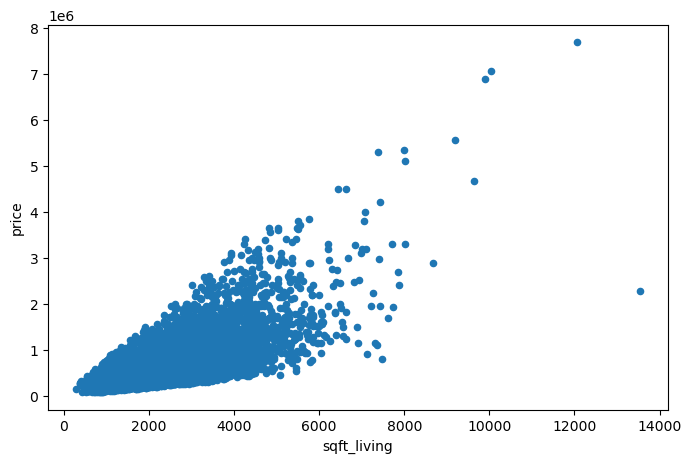

In [12]:
housing.plot.scatter(
    x="sqft_living",
    y="price",
    figsize=(8,5)
)

plt.show()

## 11. Consulta SQL

Se ejecuta una consulta SQL simple sobre la base de datos creada.

In [13]:
consulta = pd.read_sql("""
SELECT
    zipcode,
    AVG(price) AS promedio_precio
FROM housing
GROUP BY zipcode
ORDER BY promedio_precio DESC
LIMIT 10
""", conexion)

consulta

,zipcode,promedio_precio
0,98039,2.160607e+06
1,98004,1.355927e+06
2,98040,1.194230e+06
3,98112,1.095499e+06
4,98102,9.012583e+05
5,98109,8.796236e+05
6,98105,8.628252e+05
7,98006,8.596848e+05
8,98119,8.494480e+05
9,98005,8.101649e+05


## 12. Conclusión

En esta práctica se implementó una estructura básica de Data Lake y procesamiento de datos utilizando Python. También se creó una base de datos para almacenar información del dataset Housing y se realizaron procesos ETL básicos.

Finalmente, se exploró la información mediante KPIs, consultas y análisis adicionales que permiten comprender mejor el comportamiento de las viviendas y generar información útil para el negocio.